<a name="top" id="top"></a>

<div align="center">
    <h1>QUBO &amp; Ising Models</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/jvpcms">João Victor Souza</a>
    <br>
    <i>Computer Engineering Department, Military Institute of Engineering (IME)</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/2-QUBO.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

## Setup

### Google Colab
Click the badge above to open this notebook in Colab. The notebook installs or activates dependencies in the setup cells below.

### Local installation
Run the following from the repository root before opening this notebook locally:

```bash
julia --project=notebooks_jl -e 'using Pkg; Pkg.instantiate()'
```

Run the command from the repository root before opening the Julia notebook locally.

**GLPK (required for ILP sections):**
- macOS: `brew install glpk`
- Ubuntu/Debian: `sudo apt-get install glpk-utils`
- Windows: download from http://winglpk.sourceforge.net/


## Colab Instructions

If not in a Colab notebook, continue to the next section.

1. Work on a copy of this notebook: _File_ > _Save a copy in Drive_.
2. Execute the following cell to install Julia, IJulia, the shared notebook project, and the precompiled QUBONotebooks sysimage. This can take a couple of minutes.
3. Reload this page after the installation finishes, then continue with **Activate Environment**.


In [ ]:
%%shell

bash <(curl -s "https://raw.githubusercontent.com/JuliaQUBO/QUBONotebooks/main/scripts/install-colab-julia.sh")

### Activate Environment

In [1]:
import Pkg
Pkg.activate(@__DIR__)
python_warning_filter = "ignore:invalid escape sequence:SyntaxWarning"
python_warning_filters = String.(filter(!isempty, split(get(ENV, "PYTHONWARNINGS", ""), ",")))
if python_warning_filter ∉ python_warning_filters
    push!(python_warning_filters, python_warning_filter)
    ENV["PYTHONWARNINGS"] = join(python_warning_filters, ",")
end
Pkg.instantiate(; io = devnull)


  Activating project at `./notebooks_jl`


## Learning objectives

By the end of this notebook you will be able to:

1. Describe QUBO and Ising model forms and the role of linear, quadratic, and offset terms.
2. Convert constrained binary optimization problems into QUBO models using penalty terms.
3. Build and solve QUBO/Ising models with JuliaQUBO tooling and simulated annealing.
4. Validate sampled solutions and connect QUBO penalties to graph-coloring feasibility.


## Prerequisites

**Mathematical background:** Binary variables, matrix notation, quadratic objectives, and basic graph terminology.  
**Prior notebooks:** Notebook 1 (MathProg) or equivalent experience with binary integer programming.  
**Accounts required:** None; all examples use local or Colab Julia packages.  
**Julia version:** Julia 1.10+ with the notebook project and JuliaQUBO packages instantiated.


In [2]:
using Karnak


In [3]:
using LinearAlgebra


In [4]:
using Graphs


In [5]:
using JuMP


In [6]:
using QUBO


In [7]:
using Plots


In [8]:
using GLPK


In [9]:
using DWave


    CondaPkg Found dependencies: <LOCAL_JULIA_DEPOT>/packages/DWave/Gf7Yh/CondaPkg.toml


    CondaPkg Found dependencies: <JULIA_DEPOT>/packages/CondaPkg/0UqYV/CondaPkg.toml


    CondaPkg Found dependencies: <JULIA_DEPOT>/packages/PythonCall/5WGSP/CondaPkg.toml


    CondaPkg Found dependencies: <JULIA_DEPOT>/packages/PythonPlot/oS8x4/CondaPkg.toml


    CondaPkg Initialising pixi


...

             │ <JULIA_DEPOT>/artifacts/4ae17cee0bd922f66b2c72bf2f01c22481a5ec19/bin/pixi


             │ install


             └ --manifest-path ./notebooks_jl/.CondaPkg/pixi.toml


 WARN Encountered 1 warning while parsing the manifest:
  ⚠ The `project` field is deprecated. Use `workspace` instead.
    ╭─[./notebooks_jl/.CondaPkg/pixi.toml:13:1]
 12 │     
 13 │ ╭─▶ [project]
 14 │ │   name = ".CondaPkg"
 15 │ │   platforms = ["linux-64"]
 16 │ │   channels = ["conda-forge", "anaconda"]
 17 │ │   channel-priority = "strict"
 18 │ ├─▶ description = "automatically generated by CondaPkg.jl"
    · ╰──── replace this with 'workspace'
 19 │     
    ╰────



✔ The default environment has been installed.


In [10]:
using Luxor

In [11]:
Pkg.status()

Status `./notebooks_jl/Project.toml`
  [7c4d4715] AmplNLWriter v1.4.1
  [f01c122e] BinaryWrappers v0.2.0
  [159f3aea] Cairo v1.1.1
  [9961bab8] Cbc v1.3.0
  [4d534982] DWave v0.7.6 `https://github.com/JuliaQUBO/DWave.jl#v0.7.6`
  [186bb1d3] Fontconfig v0.4.1
  [60bf3e95] GLPK v1.2.1
  [a2cc645c] GraphPlot v0.6.2
  [86223c79] Graphs v1.14.0
⌃ [87dc4568] HiGHS v1.24.0
  [7073ff75] IJulia v1.34.4
  [b6b21f68] Ipopt v1.15.0
⌅ [682c06a0] JSON v0.21.4
  [4076af6c] JuMP v1.30.1
  [cd156443] Karnak v1.2.0
  [ae8d54c2] Luxor v4.5.0
  [b8f27783] MathOptInterface v1.51.1
  [442fdcdd] Measures v0.3.3
  [15e1cf62] NPZ v0.4.3
  [91a5bcdd] Plots v1.41.6
⌃ [c3e4b0f8] Pluto v1.0.1
  [6099a3de] PythonCall v0.9.35
  [274fc56d] PythonPlot v1.0.6
  [ce8c2e91] QUBO v0.6.2
  [276daf66] SpecialFunctions v2.8.0
  [2913bbd2] StatsBase v0.34.12
  [f3b207a7] StatsPlots v0.15.8
  [a5390f91] ZipFile v0.10.1
  [29cba6d7] Bonmin_jll v100.800.902+0
  [f09e9e23] Couenne_jll v0.500.802+0
  [1493ae25] lib4ti2_jll v1.6.10

## Quadratic Unconstrained Binary Optimization

This notebook will explain the basics of the QUBO modeling.
In order to implement the different QUBO formulations we will use **[JuMP](https://jump.dev)**, and then solve them using **[neal](https://github.com/dwavesystems/dwave-neal)**'s implementation of simulated annealing.
We will also leverage the use of **[QUBO.jl](https://github.com/JuliaQUBO/QUBO.jl)** to translate constraint satisfaction problems to QUBOs.
Finally, we will use **[Graphs.jl](https://github.com/JuliaGraphs/Graphs.jl)** for network models/graphs.

## Problem statement

We define a QUBO as the following optimization problem:

$$
\min_{x \in \{0,1 \}^n} \sum_{(ij) \in E(G)} Q_{ij}x_i x_j + \sum_{i \in V(G)}Q_{ii}x_i + \beta = \min_{x \in \{0,1 \}^n}  \mathbf{x}' \mathbf{Q} \mathbf{x} + \beta
$$

where we optimize over binary variables $x \in \{ 0,1 \}^n$, on a constrained graph $G(V,E)$ defined by a weighted adjacency matrix $\mathbf{Q}$.
We also include an arbitrary offset  $\beta$.

### Example

Suppose we want to solve the following problem via QUBO

$$
\begin{array}{rl}
\displaystyle%
\min_{\mathbf{x}} & 2x_1+4x_2+4x_3+4x_4+4x_5+4x_6+5x_7+4x_8+5x_9+6x_{10}+5x_{11} \\
\textrm{s.t.}     & \begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1\\
0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 1\\
0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}\mathbf{x}=
\begin{bmatrix}
1\\
1\\
1
\end{bmatrix} \\
~ & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

First we would write this problem as a an unconstrained one by penalizing the linear constraints as quadratics in the objective.
Let's first define the problem parameters.

In [12]:
A = [
    1 0 0 1 1 1 0 1 1 1 1
    0 1 0 1 0 1 1 0 1 1 1
    0 0 1 0 1 0 1 1 1 1 1
]
b = [1, 1, 1]
c = [2, 4, 4, 4, 4, 4, 5, 4, 5, 6, 5];

In order to define the $\mathbf{Q}$ matrix, we first write the problem

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} &\mathbf{c}' \mathbf{x} \\
    \textrm{s.t.}     & \mathbf{A}\mathbf{x} = \mathbf{b} \\
    ~                 & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

as follows:

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} & \mathbf{c}' \mathbf{x} + \rho (\mathbf{A}\mathbf{x}-\mathbf{b})' (\mathbf{A}\mathbf{x}-\mathbf{b}) \\
    \textrm{s.t.}     & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

Exploiting the fact that $x^2=x$ for $x \in \{0,1\}$, we can make the linear terms appear in the diagonal of the $\mathbf{Q}$ matrix.

$$
\rho(\mathbf{A}\mathbf{x}-\mathbf{b})'(\mathbf{A}\mathbf{x}-\mathbf{b}) = \rho( \mathbf{x}'(\mathbf{A}'\mathbf{A}) \mathbf{x} - 2(\mathbf{A}'\mathbf{b}) \mathbf{x} + \mathbf{b}'\mathbf{b} )
$$

### Penalty parameter rationale

The penalty term must be large enough that any infeasible assignment is worse than the objective improvement it might gain by violating the constraint. For a binary constraint `A x = b`, the residual `A x - b` is integer-valued; the smallest nonzero violation has squared penalty at least 1. A conservative sufficient bound is `rho = sum(abs(c)) + epsilon`, because changing binary variables can improve the linear objective by at most `sum(abs(c_i))`.

Worked example: if `sum(abs(c_i)) = 6` and `rho = 5.9`, an infeasible assignment with violation 1 can gain 6 objective units while paying only 5.9 penalty units, so it can look 0.1 units better than a feasible assignment. Choosing `rho = 6 + epsilon` closes that gap for this bounded binary model.

This is a sufficient bound for this model family, not a universal rule. Constraints with non-binary variables, non-integer residuals, or a larger objective range need a problem-specific penalty analysis. See Glover, Kochenberger, and Du (2019), "A Tutorial on Formulating and Using QUBO Models."


In [13]:
ϵ = 1
ρ = sum(abs, c) + ϵ
Q = diagm(c) + ρ * (A'A - 2 * diagm(A'b))
β = ρ * b'b

display(Q)
println(β)

11×11 Matrix{Int64}:
 -46    0    0   48   48   48    0   48    48    48    48
   0  -44    0   48    0   48   48    0    48    48    48
   0    0  -44    0   48    0   48   48    48    48    48
  48   48    0  -92   48   96   48   48    96    96    96
  48    0   48   48  -92   48   48   96    96    96    96
  48   48    0   96   48  -92   48   48    96    96    96
   0   48   48   48   48   48  -91   48    96    96    96
  48    0   48   48   96   48   48  -92    96    96    96
  48   48   48   96   96   96   96   96  -139   144   144
  48   48   48   96   96   96   96   96   144  -138   144
  48   48   48   96   96   96   96   96   144   144  -139

144


We can visualize the graph that defines this instance using the $\mathbf{Q}$ matrix as the adjacency matrix of a graph.

In [14]:
G = SimpleGraph(Q)
println(G)

SimpleGraph{Int64}(58, 

[[1, 4, 5, 6, 8, 9, 10, 11], [2, 4, 6, 7, 9, 10, 11], [3, 5, 7, 8, 9, 10, 11], [1, 2, 4, 5, 6, 7, 8, 9, 10, 11], [1, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2, 4, 5, 6, 7, 8, 9, 10, 11], [2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]])


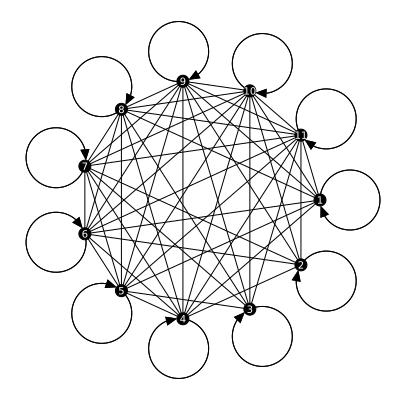

In [15]:
@drawsvg(
    begin
        sethue("black")
        background("white")
        drawgraph(
            G;
            margin       = 80,
            vertexlabels = 1:11,
        )
    end,
    400, 400
)

Let's define a QUBO model and then solve it using enumeration and D-Wave's simulated annealing (eventually with Quantum annealling too!).

In [16]:
# Define empty model
qubo_model = Model()

# Define the variables
@variable(qubo_model, x_qubo[1:11], Bin, base_name = "x")

# Define the objective function
@objective(qubo_model, Min, x_qubo' * Q * x_qubo + β)

# Print the model
print(qubo_model)

Since the problem is relatively small ($11$ variables, $2^{11}=2048$ combinations), we can afford to enumerate all the solutions.

In [17]:
# Here we solve the optimization problem with GLPK
set_optimizer(qubo_model, ExactSampler.Optimizer)

optimize!(qubo_model)

qubo_x = round.(Int, value.(x_qubo))

# Display solution of the problem
println(solution_summary(qubo_model))
println("* x = $qubo_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : Exact Sampler
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 2048
│ └ raw_status         : optimal
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION


│ ├ objective_value      : 5.00000e+00
│ └ dual_objective_value : 1.44000e+02
└ Work counters
  └ solve_time (sec)   : 3.34121e-01
* x = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


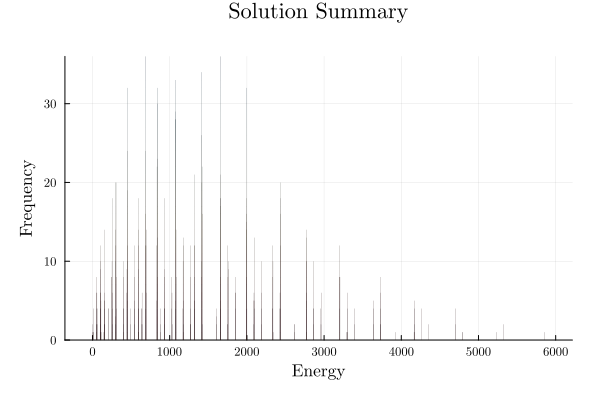

In [18]:
plot(QUBOTools.EnergyFrequencyPlot(QUBOTools.solution(QUBOTools.backend(qubo_model))))

Let's now solve this QUBO via traditional Integer Programming.

In [19]:
qubo_ilp_model = Model()

@variable(qubo_ilp_model, x_qubo_ilp[1:11], Bin, base_name = "x")
@variable(qubo_ilp_model, y[1:11, 1:11], Bin)

@objective(
    qubo_ilp_model,
    Min,
    sum(Q[i,j] * (i == j ? x_qubo_ilp[i] : y[i,j]) for i=1:11, j=1:11) +  β
)

@constraint(qubo_ilp_model, c1[i=1:11,j=1:11;i!=j], y[i,j] >= x_qubo_ilp[i] + x_qubo_ilp[j] - 1)
@constraint(qubo_ilp_model, c2[i=1:11,j=1:11;i!=j], y[i,j] <= x_qubo_ilp[i])
@constraint(qubo_ilp_model, c3[i=1:11,j=1:11;i!=j], y[i,j] <= x_qubo_ilp[j])

println(qubo_ilp_model)

Min -46 x[1] + 48 y[1,4] + 48 y[1,5] + 48 y[1,6] + 48 y[1,8] + 48 y[1,9] + 48 y[1,10] + 48 y[1,11] - 44 x[2] + 48 y[2,4] + 48 y[2,6] + 48 y[2,7] + 48 y[2,9] + 48 y[2,10] + 48 y[2,11] - 44 x[3] + 48 y[3,5] + 48 y[3,7] + 48 y[3,8] + 48 y[3,9] + 48 y[3,10] + 48 y[3,11] + 48 y[4,1] + 48 y[4,2] - 92 x[4] + 48 y[4,5] + 96 y[4,6] + 48 y[4,7] + 48 y[4,8] + 96 y[4,9] + [[...45 terms omitted...]] + 96 y[9,4] + 96 y[9,5] + 96 y[9,6] + 96 y[9,7] + 96 y[9,8] - 139 x[9] + 144 y[9,10] + 144 y[9,11] + 48 y[10,1] + 48 y[10,2] + 48 y[10,3] + 96 y[10,4] + 96 y[10,5] + 96 y[10,6] + 96 y[10,7] + 96 y[10,8] + 144 y[10,9] - 138 x[10] + 144 y[10,11] + 48 y[11,1] + 48 y[11,2] + 48 y[11,3] + 96 y[11,4] + 96 y[11,5] + 96 y[11,6] + 96 y[11,7] + 96 y[11,8] + 144 y[11,9] + 144 y[11,10] - 139 x[11] + 144
Subject to
 

c1[1,2] : -x[1] - x[2] + y[1,2] ≥ -1
 c1[1,3] : -x[1] - x[3] + y[1,3] ≥ -1
 c1[1,4] : -x[1] - x[4] + y[1,4] ≥ -1
 c1[1,5] : -x[1] - x[5] + y[1,5] ≥ -1
 c1[1,6] : -x[1] - x[6] + y[1,6] ≥ -1
 c1[1,7] : -x[1] - x[7] + y[1,7] ≥ -1
 c1[1,8] : -x[1] - x[8] + y[1,8] ≥ -1
 c1[1,9] : -x[1] - x[9] + y[1,9] ≥ -1
 c1[1,10] : -x[1] - x[10] + y[1,10] ≥ -1
 c1[1,11] : -x[1] - x[11] + y[1,11] ≥ -1
 c1[2,1] : -x[1] - x[2] + y[2,1] ≥ -1
 c1[2,3] : -x[2] - x[3] + y[2,3] ≥ -1
 c1[2,4] : -x[2] - x[4] + y[2,4] ≥ -1
 c1[2,5] : -x[2] - x[5] + y[2,5] ≥ -1
 c1[2,6] : -x[2] - x[6] + y[2,6] ≥ -1
 c1[2,7] : -x[2] - x[7] + y[2,7] ≥ -1
 c1[2,8] : -x[2] - x[8] + y[2,8] ≥ -1
 c1[2,9] : -x[2] - x[9] + y[2,9] ≥ -1
 c1[2,10] : -x[2] - x[10] + y[2,10] ≥ -1
 c1[2,11] : -x[2] - x[11] + y[2,11] ≥ -1
 c1[3,1] : -x[1] - x[3] + y[3,1] ≥ -1
 c1[3,2] : -x[2] - x[3] + y[3,2] ≥ -1
 c1[3,4] : -x[3] - x[4] + y[3,4] ≥ -1
 c1[3,5] : -x[3] - x[5] + y[3,5] ≥ -1
 c1[3,6] : -x[3] - x[6] + y[3,6] ≥ -1
 c1[3,7] : -x[3] - x[7] + y[3,7] ≥ -1
 

In [20]:
set_optimizer(qubo_ilp_model, GLPK.Optimizer)

optimize!(qubo_ilp_model)

qubo_ilp_x = round.(Int, value.(x_qubo_ilp))

println(solution_summary(qubo_ilp_model))
println("* x = $qubo_ilp_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : GLPK
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Solution is optimal
│ └ objective_bound    : 5.00000e+00
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 5.00000e+00
│ └ relative_gap         : 9.60000e+00
└ Work counters
  └ solve_time (sec)   : 6.69789e-03
* x = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


We observe that the optimal solution of this problem is $x_{9} = 1, 0$ otherwise, leading to an objective value of $5$.
Notice that this problem has a degenerate optimal solution given that $x_{11} = 1, 0$ otherwise also leads to the same solution.

## Ising model

This notebook will explain the basics of the Ising model.
In order to implement the different Ising Models we will use **[JuMP](https://jump.dev)** and D-Wave's **[neal](https://github.com/dwavesystems/dwave-neal)**, for defining the Ising model and solving it with simulated annealing, respectively.
When posing the problems as Integer programs, we will model using **[JuMP](https://jump.dev/)**, an open-source Julia package, which provides a flexible access to different solvers and a general modeling framework for linear and nonlinear integer programs.
The examples solved here will make use of open-source solver **[GLPK](https://www.gnu.org/software/glpk/)** for mixed-integer linear programming.

### Problem statement

We pose the Ising problem as the following optimization problem:

$$
\min_{s \in \{ \pm 1 \}^n} H(s) = \min_{s \in \{ \pm 1 \}^n} \sum_{(i, j) \in E(G)} J_{i,j}s_is_j + \sum_{i \in V(G)} h_is_i + \beta
$$

where we optimize over spins $s \in \{ \pm 1 \}^n$, on a constrained graph $G(V,E)$, where the quadratic coefficients are $J_{i,j}$ and the linear coefficients are $h_i$.
We also include an arbitrary offset of the Ising model $\beta$.

### Example

Suppose we have an Ising model defined from

$$
h = \begin{bmatrix}
145.0 \\ 122.0 \\ 122.0 \\ 266.0 \\ 266.0 \\ 266.0 \\ 242.5 \\ 266.0 \\ 386.5 \\ 387.0 \\ 386.5
\end{bmatrix},
J = \begin{bmatrix}
0 & 0 & 0 & 24 & 24 & 24 & 0 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 24 & 0 & 24 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 0 & 24 & 0 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 0 & 24 & 48 & 24 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 24 & 24 & 48 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 24 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 72 & 72\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 72\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
\end{bmatrix} \text{ and }
\beta = 1319.5
$$
Let's solve this problem

In [21]:
h = [
    145.0,
    122.0,
    122.0,
    266.0,
    266.0,
    266.0,
    242.5,
    266.0,
    386.5,
    387.0,
    386.5,
]

J = [
    0  0  0 24 24 24  0 24 24 24 24
    0  0  0 24  0 24 24  0 24 24 24
    0  0  0  0 24  0 24 24 24 24 24
    0  0  0  0 24 48 24 24 48 48 48
    0  0  0  0  0 24 24 48 48 48 48
    0  0  0  0  0  0 24 24 48 48 48
    0  0  0  0  0  0  0 24 48 48 48
    0  0  0  0  0  0  0  0 48 48 48
    0  0  0  0  0  0  0  0  0 72 72
    0  0  0  0  0  0  0  0  0  0 72
    0  0  0  0  0  0  0  0  0  0  0
]

β = 1319.5

ising_model = Model()

@variable(ising_model, s[1:11], Spin)

@objective(ising_model, Min, s' * J * s + h' * s + β)

println(ising_model)

Min 24 s[4]*s[1] + 24 s[4]*s[2] + 24 s[5]*s[1] + 24 s[5]*s[3] + 24 s[5]*s[4] + 24 s[6]*s[1] + 24 s[6]*s[2] + 48 s[6]*s[4] + 24 s[6]*s[5] + 24 s[7]*s[2] + 24 s[7]*s[3] + 24 s[7]*s[4] + 24 s[7]*s[5] + 24 s[7]*s[6] + 24 s[8]*s[1] + 24 s[8]*s[3] + 24 s[8]*s[4] + 48 s[8]*s[5] + 24 s[8]*s[6] + 24 s[8]*s[7] + 24 s[9]*s[1] + 24 s[9]*s[2] + 24 s[9]*s[3] + 48 s[9]*s[4] + 48 s[9]*s[5] + 48 s[9]*s[6] + 48 s[9]*s[7] + 48 s[9]*s[8] + 24 s[10]*s[1] + 24 s[10]*s[2] + 24 s[10]*s[3] + 48 s[10]*s[4] + 48 s[10]*s[5] + 48 s[10]*s[6] + 48 s[10]*s[7] + 48 s[10]*s[8] + 72 s[10]*s[9] + 24 s[11]*s[1] + 24 s[11]*s[2] + 24 s[11]*s[3] + 48 s[11]*s[4] + 48 s[11]*s[5] + 48 s[11]*s[6] + 48 s[11]*s[7] + 48 s[11]*s[8] + 72 s[11]*s[9] + 72 s[11]*s[10] + 145 s[1] + 122 s[2] + 122 s[3] + 266 s[4] + 266 s[5] + 266 s[6] + 242.5 s[7] + 266 s[8] + 386.5 s[9] + 387 s[10] + 386.5 s[11] + 1319.5
Subject to
 

s[1] spin
 s[2] spin
 s[3] spin
 s[4] spin
 s[5] spin
 s[6] spin
 s[7] spin
 s[8] spin
 s[9] spin
 s[10] spin
 s[11] spin



In [22]:
set_optimizer(ising_model, ExactSampler.Optimizer)

optimize!(ising_model)

ising_s = round.(Int, value.(s))

# Display solution of the problem
println(solution_summary(ising_model))
println("* s = $ising_s")

solution_summary(; result = 1, verbose = false)
├ solver_name          : Exact Sampler
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 2048
│ └ raw_status         : optimal
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 5.00000e+00
│ └ dual_objective_value : 1.31950e+03
└ Work counters
  └ solve_time (sec)   : 8.17876e-04
* s = [-1, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1]


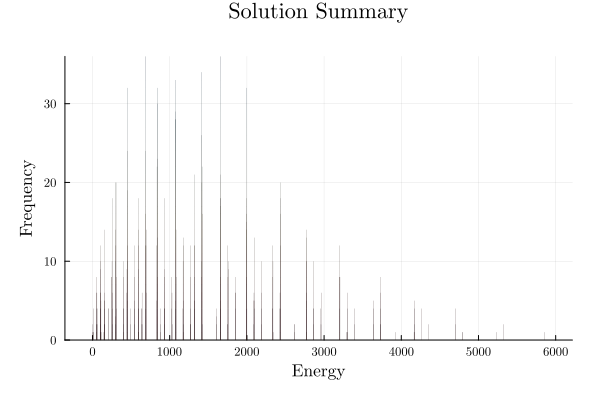

In [23]:
plot(QUBOTools.EnergyFrequencyPlot(QUBOTools.solution(QUBOTools.backend(ising_model))))

Before rebuilding the Ising model as a binary ILP, use the `QUBOTools.qubo` binary convention $s = 2x - 1$.

Under this substitution, the Ising Hamiltonian becomes a QUBO with a separate linear vector $L$, a strictly off-diagonal quadratic matrix $Q$, and an offset $\beta$. The scale and offset are already included in those returned pieces, so the ILP objective must include both the $L_i x_i$ terms and the off-diagonal $Q_{ij} y_{ij}$ terms.

In [24]:
n, L, Q, α, β = QUBOTools.qubo(QUBOTools.backend(ising_model), :dense; sense = :min)

QUBOTools.Form{Float64, QUBOTools.DenseLinearForm{Float64}, QUBOTools.DenseQuadraticForm{Float64}}(11, QUBOTools.DenseLinearForm{Float64}([-46.0, -44.0, -44.0, -92.0, -92.0, -92.0, -91.0, -92.0, -139.0, -138.0, -139.0]), QUBOTools.DenseQuadraticForm{Float64}([0.0 0.0 … 96.0 96.0; 0.0 0.0 … 96.0 96.0; … ; 0.0 0.0 … 0.0 288.0; 0.0 0.0 … 0.0 0.0]), 1.0, 144.0, QUBOTools.Frame(QUBOTools.Min, QUBOTools.BoolDomain))

In [25]:
ising_ilp_model = Model()

@variable(ising_ilp_model, x_ising_ilp[1:n], Bin, base_name = "x")
@variable(ising_ilp_model, y[1:n, 1:n], Bin)

@objective(
    ising_ilp_model,
    Min,
    sum(L[i] * x_ising_ilp[i] for i in 1:n) +
    sum(Q[i,j] * y[i,j] for i in 1:n, j in 1:n if i != j) +
    β
)

@constraint(ising_ilp_model, c1[i=1:n,j=1:n;i!=j], y[i,j] >= x_ising_ilp[i] + x_ising_ilp[j] - 1)
@constraint(ising_ilp_model, c2[i=1:n,j=1:n;i!=j], y[i,j] <= x_ising_ilp[i])
@constraint(ising_ilp_model, c3[i=1:n,j=1:n;i!=j], y[i,j] <= x_ising_ilp[j])

println(ising_ilp_model)

Min -46 x[1] - 44 x[2] - 44 x[3] - 92 x[4] - 92 x[5] - 92 x[6] - 91 x[7] - 92 x[8] - 139 x[9] - 138 x[10] - 139 x[11] + 96 y[1,4] + 96 y[1,5] + 96 y[1,6] + 96 y[1,8] + 96 y[1,9] + 96 y[1,10] + 96 y[1,11] + 96 y[2,4] + 96 y[2,6] + 96 y[2,7] + 96 y[2,9] + 96 y[2,10] + 96 y[2,11] + 96 y[3,5] + 96 y[3,7] + 96 y[3,8] + 96 y[3,9] + 96 y[3,10] + 96 y[3,11] + 96 y[4,5] + 192 y[4,6] + 96 y[4,7] + 96 y[4,8] + 192 y[4,9] + 192 y[4,10] + 192 y[4,11] + 96 y[5,6] + 96 y[5,7] + 192 y[5,8] + 192 y[5,9] + 192 y[5,10] + 192 y[5,11] + 96 y[6,7] + 96 y[6,8] + 192 y[6,9] + 192 y[6,10] + 192 y[6,11] + 96 y[7,8] + 192 y[7,9] + 192 y[7,10] + 192 y[7,11] + 192 y[8,9] + 192 y[8,10] + 192 y[8,11] + 288 y[9,10] + 288 y[9,11] + 288 y[10,11] + 144
Subject to
 c1[1,2] : -x[1] - x[2] + y[1,2] ≥ -1
 c1[1,3] : -x[1] - x[3] + y[1,3] ≥ -1
 c1[1,4] : -x[1] - x[4] + y[1,4] ≥ -1
 c1[1,5] : -x[1] - x[5] + y[1,5] ≥ -1
 c1[1,6] : -x[1] - x[6] + y[1,6] ≥ -1
 c1[1,7] : -x[1] - x[7] + y[1,7] ≥ -1
 c1[1,8] : -x[1] - x[8] + y[1,8] 

In [26]:
set_optimizer(ising_ilp_model, GLPK.Optimizer)

optimize!(ising_ilp_model)

ising_ilp_x = round.(Int, value.(x_ising_ilp))
ising_ilp_s = 2 .* ising_ilp_x .- 1

@assert ising_ilp_s == ising_s
@assert isapprox(objective_value(ising_ilp_model), objective_value(ising_model); atol = 1e-6)

println(solution_summary(ising_ilp_model))
println("* x = $ising_ilp_x")
println("* s = $ising_ilp_s")

solution_summary(; result = 1, verbose = false)
├ solver_name          : GLPK
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Solution is optimal
│ └ objective_bound    : 5.00000e+00
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 5.00000e+00
│ └ relative_gap         : 7.40000e+00
└ Work counters
  └ solve_time (sec)   : 3.13711e-03
* x = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
* s = [-1, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1]


The corrected ILP solution is $x = [0,0,0,0,0,0,0,0,1,0,0]$, which maps back to $s = [-1,-1,-1,-1,-1,-1,-1,-1,+1,-1,-1]$ through $s = 2x - 1$. This matches the ExactSampler solution and gives objective value $5.0$.

## From QUBO to Ising

QUBO and Ising models describe the same binary search space with different variable conventions. The QUBO form uses variables in `{0, 1}`, while the Ising form uses spins in `{-1, +1}`. Moving between them changes the linear terms, quadratic terms, and offset, but not the underlying set of assignments. This equivalence lets us compare exact integer-programming solves with simulated annealing on the same problem.


Let's now solve the QUBO problem using Simulated Annealing

In [27]:
set_optimizer(qubo_model, DWave.Neal.Optimizer)

set_optimizer_attribute(qubo_model, "num_reads", 1_000)

optimize!(qubo_model)

qubo_x = round.(Int, value.(x_qubo))

println(solution_summary(qubo_model))
println("* x = $qubo_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : D-Wave Neal Simulated Annealing Sampler
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 13
│ └ raw_status         : locally_solved
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 5.00000e+00
│ └ dual_objective_value : 1.44000e+02
└ Work counters
  └ solve_time (sec)   : 6.06210e-01
* x = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


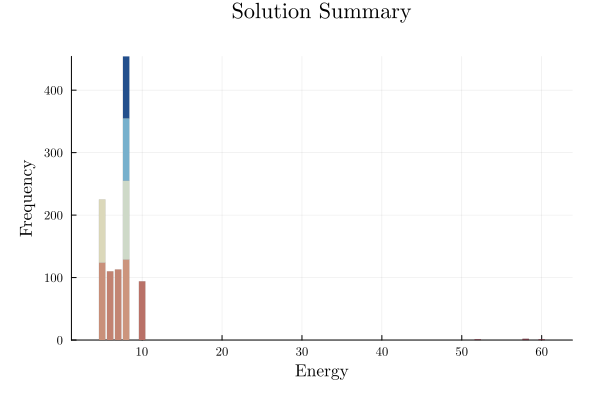

In [28]:
plot(QUBOTools.EnergyFrequencyPlot(QUBOTools.solution(QUBOTools.backend(qubo_model))))

Notice that this is the same example we have been solving earlier (via Integer Programming in the Quiz 1 and Ising model above).

## From penalty models to graph coloring

The previous examples used penalties to enforce algebraic constraints. Graph coloring uses the same idea with one-hot variables: each vertex must choose exactly one color, and adjacent vertices may not share a color. Violating either rule adds a penalty to the QUBO objective, so low-energy samples correspond to valid colorings when the penalties are large enough.


Let's solve the graph coloring problem using QUBO.

#### Vertex $k$-coloring of graphs

Given a graph $G(V, E)$, where $V$ is the set of vertices and $E$ is the set of edges of $G$, and a positive integer $k$, we ask if it is possible to assign a color to every vertex from $V$, such that adjacent vertices have different colors assigned.

$G(V, E)$ has $12$ vertices and $23$ edges.
We ask if the graph is $3$–colorable.
Let’s first encode $V$ and $E$ using Julia data structures:

**Note:** This second tutorial is heavily inspired in D-Wave's Map coloring of Canada found **[here](https://docs.ocean.dwavesys.com/en/stable/examples/map_coloring.html)**.

In [29]:
V = 1:12
E = [
    (1,2), (1,4), (1,6), (1,12),
    (2,3), (2,5), (2,7),
    (3,8), (3,10),
    (4,9), (4,11),
    (5,6), (5,9), (5,12),
    (6,7), (6,10),
    (7,8), (7,11),
    (8,9), (8,12),
    (9,10),
    (10,11),
    (11,12),
]

G = SimpleGraph(Edge.(E))

{12, 23} undirected simple Int64 graph

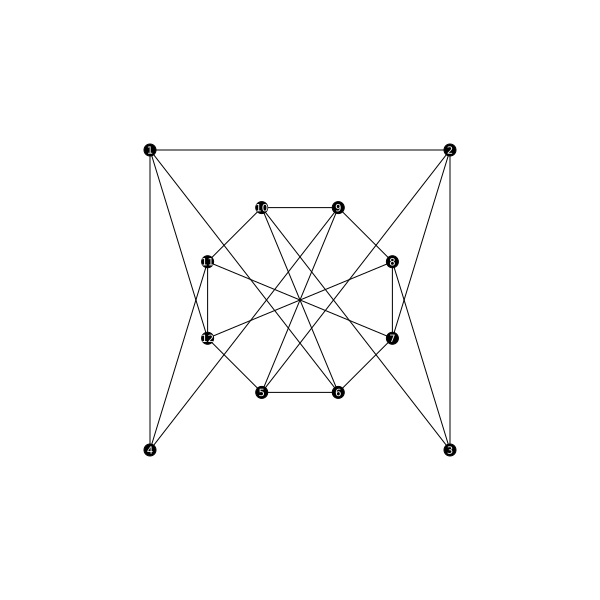

In [30]:
graph_layout = Vector{Point}(undef, 12)

graph_layout[1] = Point(-1.5,-1.5)
graph_layout[2] = Point(1.5,-1.5)
graph_layout[3] = Point(1.5,1.5)
graph_layout[4] = Point(-1.5,1.5)

for i in 5:12
    graph_layout[i] = Point(cos((2i+1) * π/8), -sin((2i+1) * π/8))
end

@drawsvg(
    begin
        sethue("black")
        background("white")
        drawgraph(
            G;
            layout=100 * graph_layout,
            vertexlabels = V,
        )
    end,
)

In [31]:
# Valid configurations for the constraint that each node select a single color, in this case we want to use 3 colors
color_model = direct_model(ToQUBO.Optimizer(DWave.Neal.Optimizer))

@variable(color_model, c[1:12,1:3], Bin)

# Each node must be colored with exactly one color
@constraint(color_model, unique[i=1:12], sum(c[i,:]) == 1)

# Add constraint that each pair of nodes with a shared edge not both select one color
@constraint(color_model, neigh[(i,j) ∈ E, k=1:3], c[i, k] * c[j,k] == 0);

In [32]:
optimize!(color_model)

color_ρ = get_optimizer_attribute.(neigh, ToQUBO.Attributes.ConstraintEncodingPenalty())

color_c = round.(Int, value.(c))

println(solution_summary(color_model))
println("* c = $color_c")
println("* ρ = $color_ρ")

solution_summary(; result = 1, verbose = false)
├ solver_name          : Virtual QUBO Model
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 191
│ └ raw_status         : locally_solved
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ └ objective_value      : 0.00000e+00
└ Work counters
  └ solve_time (sec)   : 5.58393e-01
* c = [1 0 0; 0 1 0; 0 0 1; 0 0 1; 1 0 0; 0 1 0; 0 0 1; 1 0 0; 0 1 0; 1 0 0; 0 1 0; 0 0 1]
* ρ = 2-dimensional DenseAxisArray{Float64,2,...} with index sets:
    Dimension 1, [(1, 2), (1, 4), (1, 6), (1, 12), (2, 3), (2, 5), (2, 7), (3, 8), (3, 10), (4, 9)  …  (5, 12), (6, 7), (6, 10), (7, 8), (7, 11), (8, 9), (8, 12), (9, 10), (10, 11), (11, 12)]
    Dimension 2, Base.OneTo(3)
And data, a 23×3 Matrix{Float64}:
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.

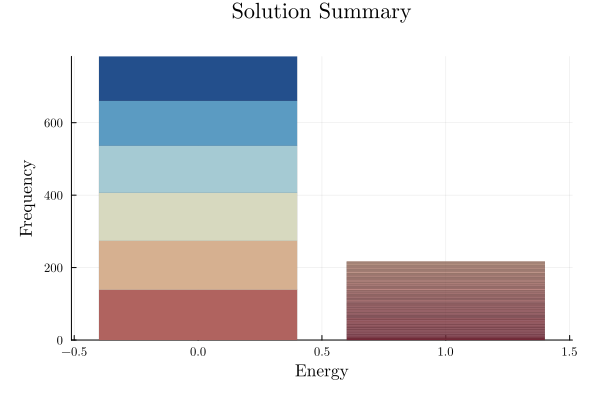

In [33]:
QUBOTools.EnergyFrequencyPlot(QUBOTools.solution(JuMP.backend(color_model).optimizer)) |> plot

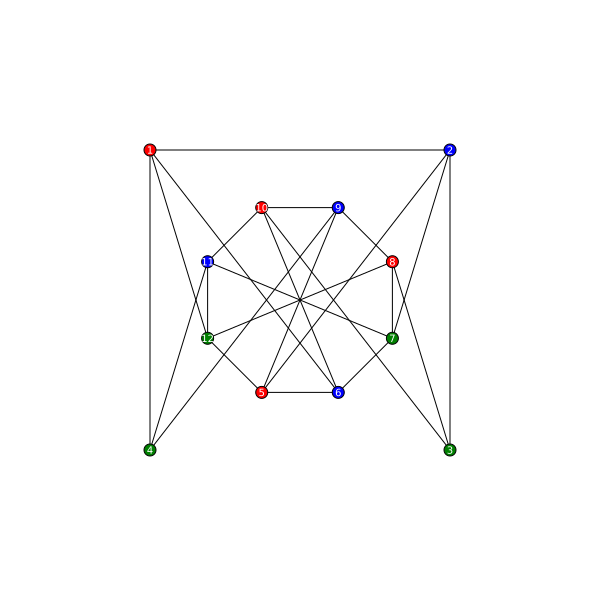

In [34]:
@drawsvg(
    begin
        sethue("black")
        background("white")
        drawgraph(
            G;
            layout=100 * graph_layout,
            vertexlabels = V,
            vertexfillcolors = (v) -> begin
                if color_c[v,1] > 0
                    return colorant"red"
                elseif color_c[v,2] > 0
                    return colorant"blue"
                elseif color_c[v,3] > 0
                    return colorant"green"
                else
                    return colorant"white"
                end
            end
        )
    end,
)

## Practice checkpoints

Use these checkpoints during the workshop to test the main ideas before moving on.

In [35]:
# =============================================================================
# EXERCISE 1: Build a small QUBO by hand
# =============================================================================
# Write the QUBO coefficients for a three-variable penalty model before using any helper function. Check that the lowest-energy assignment satisfies the original constraint.
#
# Hint: Enumerate all eight assignments to validate the coefficients.
#
# Your code here:
# =============================================================================

In [36]:
# SOLUTION (hidden in workshop version):
# Build and enumerate a three-variable one-hot QUBO by hand.
assignments = vec(collect(Iterators.product(0:1, 0:1, 0:1)))
linear = [-1.0, -1.0, -1.0]
quadratic = Dict((1, 2) => 2.0, (1, 3) => 2.0, (2, 3) => 2.0)
function energy(bits)
    total = 1.0
    for i in 1:3
        total += linear[i] * bits[i]
    end
    for (edge, weight) in quadratic
        i, j = edge
        total += weight * bits[i] * bits[j]
    end
    return total
end
best = sort([(Tuple(bits), energy(bits)) for bits in assignments]; by = item -> item[2])[1]
println((best_assignment = best[1], energy = best[2], feasible = sum(collect(best[1])) == 1))

(best_assignment = (1, 0, 0), energy = 0.0, feasible = true)


In [37]:
# =============================================================================
# EXERCISE 2: Stress-test the penalty parameter
# =============================================================================
# Lower rho below the sufficient bound and sample or enumerate the resulting BQM. Record the first infeasible assignment that becomes competitive with a feasible one.
#
# Hint: Keep the objective and constraints fixed so rho is the only changed input.
#
# Your code here:
# =============================================================================

In [38]:
# SOLUTION (hidden in workshop version):
# Lower rho on a tiny equality-constrained binary model and detect infeasibility.
assignments = vec(collect(Iterators.product(0:1, 0:1, 0:1)))
A_small = [1 1 0; 0 1 1]
b_small = [1, 1]
c_small = [1.0, 2.0, 1.0]
penalized_energy(bits, rho_value) = begin
    x = collect(bits)
    residual = A_small * x - b_small
    c_small' * x + rho_value * (residual' * residual)
end
rho_value = 0.25
best = sort([(Tuple(bits), penalized_energy(bits, rho_value), A_small * collect(bits) == b_small) for bits in assignments]; by = item -> item[2])[1]
println((rho = rho_value, best_assignment = best[1], energy = best[2], feasible = best[3]))

(rho = 0.25, best_assignment = (0, 0, 0), energy = 0.5, feasible = false)


In [39]:
# =============================================================================
# EXERCISE 3: Extend graph coloring
# =============================================================================
# Change the graph-coloring example to use three colors. Update the variable naming and validity checks so exactly one color is assigned per node.
#
# Hint: The exactly-one penalties scale with the number of colors, not the number of nodes.
#
# Your code here:
# =============================================================================

In [40]:
# SOLUTION (hidden in workshop version):
# Create variables and constraints for a three-color graph-coloring BQM sketch.
nodes = 1:3
edges = [(1, 2), (2, 3)]
colors = ["red", "green", "blue"]
variables = Dict((node, color) => "x_$(node)_$(color)" for node in nodes for color in colors)
one_hot_groups = [[variables[(node, color)] for color in colors] for node in nodes]
edge_conflicts = [(variables[(u, color)], variables[(v, color)]) for (u, v) in edges for color in colors]
println((one_hot_groups = one_hot_groups, edge_conflicts = edge_conflicts))

(one_hot_groups = [["x_1_red", "x_1_green", "x_1_blue"], ["x_2_red", "x_2_green", "x_2_blue"], ["x_3_red", "x_3_green", "x_3_blue"]], edge_conflicts = [("x_1_red", "x_2_red"), ("x_1_green", "x_2_green"), ("x_1_blue", "x_2_blue"), ("x_2_red", "x_3_red"), ("x_2_green", "x_3_green"), ("x_2_blue", "x_3_blue")])


## Summary

In this notebook we:

- Defined QUBO and Ising objectives and identified how coefficients encode binary optimization problems.
- Reformulated constrained binary problems with penalty terms so they can be sampled as unconstrained models.
- Used JuliaQUBO tooling and simulated annealing to solve models and inspect sampled energies.
- Modeled graph coloring directly from penalties and validated feasible color assignments.

**Learning objectives met:** You practiced reading QUBO/Ising forms, building QUBO models, applying penalty reformulations, and checking sampled solutions against the original constraints.

**Next steps:** Proceed to [Notebook 3: GAMA](3-GAMA.ipynb) to compare QUBO-style sampling with Graver-basis augmentation for structured integer programs.

**Further reading:**
- [QUBOTools.jl](https://github.com/JuliaQUBO/QUBOTools.jl)
- [D-Wave Ocean concepts](https://docs.ocean.dwavesys.com/en/stable/concepts/index.html)
- [D-Wave map coloring example](https://docs.ocean.dwavesys.com/en/stable/examples/map_coloring.html)


# References

- [Julia Colab Notebook Template](https://colab.research.google.com/github/ageron/julia_notebooks/blob/master/Julia_Colab_Notebook_Template.ipynb)
- [QuIPML22](https://github.com/bernalde/QuIPML22/)

## Validate Installation

In [41]:
versioninfo()

Julia Version 1.10.11
Commit a2b11907d7b (2026-03-09 14:59 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 36 × Intel(R) Xeon(R) w5-2565X
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, sapphirerapids)
Threads: 1 default, 0 interactive, 1 GC (on 36 virtual cores)
Environment:
  JULIA_DEPOT_PATH = <LOCAL_JULIA_DEPOT>:<JULIA_DEPOT>
  JULIA_PKG_PRECOMPILE_AUTO = 0


## Local Installation Instructions

If you don't have a Julia installation yet, consider using [juliaup](https://github.com/JuliaLang/juliaup).
Otherwise, run the next cell to install the necessary packages.

### Install Julia Packages

<div align="center">
    <a href="#top">🔝 Go back to the top 🔝</a>
</div>